In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('/Users/a111/Downloads/NetflixShows.xlsx')
data = data.drop_duplicates()
data = data.reset_index(drop=True)
del data['user rating size'], data['ratingDescription']


### Предварительная обработка данных

На данном этапе был загружен исходный датасет Netflix. Для повышения качества данных были удалены полные дубликаты записей, после чего индексы DataFrame были переиндексированы. Также были удалены признаки, которые не используются в дальнейшем анализе.

In [162]:
data.rating.nunique()

13

В нашем датасете представлено 13 возрастных групп

In [158]:
data.groupby('rating').count()['title'].sort_values(ascending=False)

rating
TV-14       106
TV-MA        82
PG           76
G            53
TV-Y         36
TV-PG        33
TV-G         29
TV-Y7-FV     25
TV-Y7        23
R            14
PG-13        12
NR           10
UR            1
Name: title, dtype: int64

Распределение контента по возрастным категориям. Для каждой категории подсчитано количество фильмов и сериалов. Категории TV-14, TV-MA, PG - занимают большую часть нашей выборки

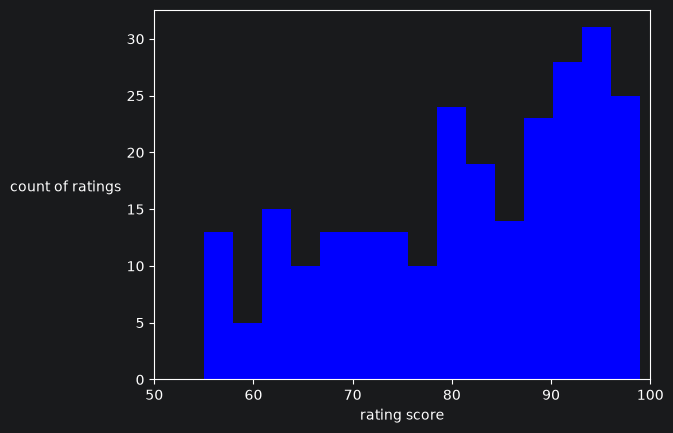

In [164]:
data.groupby('user rating score').count()['title'].sort_values(ascending=False)
plt.hist(data['user rating score'].dropna(), bins=15, color='blue')
plt.xlabel('rating score')
plt.ylabel('count of ratings', rotation=0, ha='right')
plt.xlim(50, 100)
plt.show()

In [165]:
data['user rating score'].describe()

count    256.000000
mean      81.398438
std       12.730904
min       55.000000
25%       71.000000
50%       83.500000
75%       93.000000
max       99.000000
Name: user rating score, dtype: float64


### Анализ пользовательских оценок

На данном этапе исследуется распределение пользовательских оценок контента. Сначала определяется количество фильмов и сериалов для каждого значения рейтинга. Затем с помощью гистограммы визуализируется распределение оценок в диапазоне от 50 до 100 (так как значений < 55 нет). В завершение рассчитываются основные статистические характеристики оценок: количество наблюдений, среднее значение, стандартное отклонение, минимум, максимум и квартили.

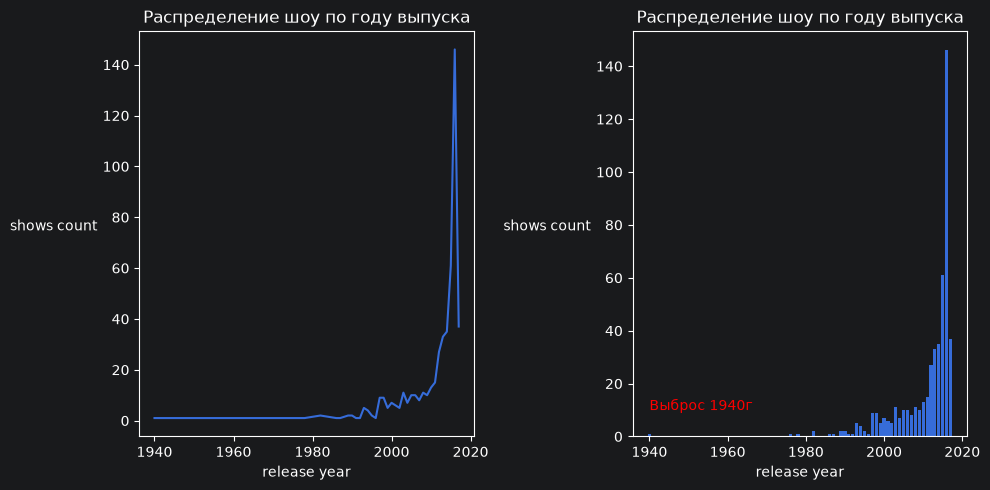

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(data.groupby('release year').size())
axes[0].set_xlabel('release year')
axes[0].set_ylabel('shows count', rotation=0, ha='right')
axes[0].set_title('Распределение шоу по году выпуска')
ans = data.groupby('release year').size()
axes[1].bar(ans.index, ans.values)
axes[1].set_xlabel('release year')
axes[1].set_ylabel('shows count', rotation=0, ha='right')
axes[1].set_title('Распределение шоу по году выпуска')
x_coord = min(ans.index)
y_coord = 10
axes[1].text(x_coord, y_coord, 'Выброс 1940г',color='red')
plt.tight_layout()
plt.show()

### Анализ количества контента по годам выпуска

На данном этапе исследуется количество фильмов и сериалов, выпущенных в каждый год. Первый график построен с помощью `plot`. Однако из-за масштаба графика значения за период 1940–1980 годов визуально выглядят близкими к нулю. Поэтому для более наглядного отображения количества записей по каждому году дополнительно построен столбчатый график (`bar`). На нём также отдельно отмечена запись с годом выпуска 1940, которая значительно отличается от остальных значений. До 1990 года было выпущено 9 шоу, будем считать их выбросами. Давайте разберем распределение контента с 1990 года

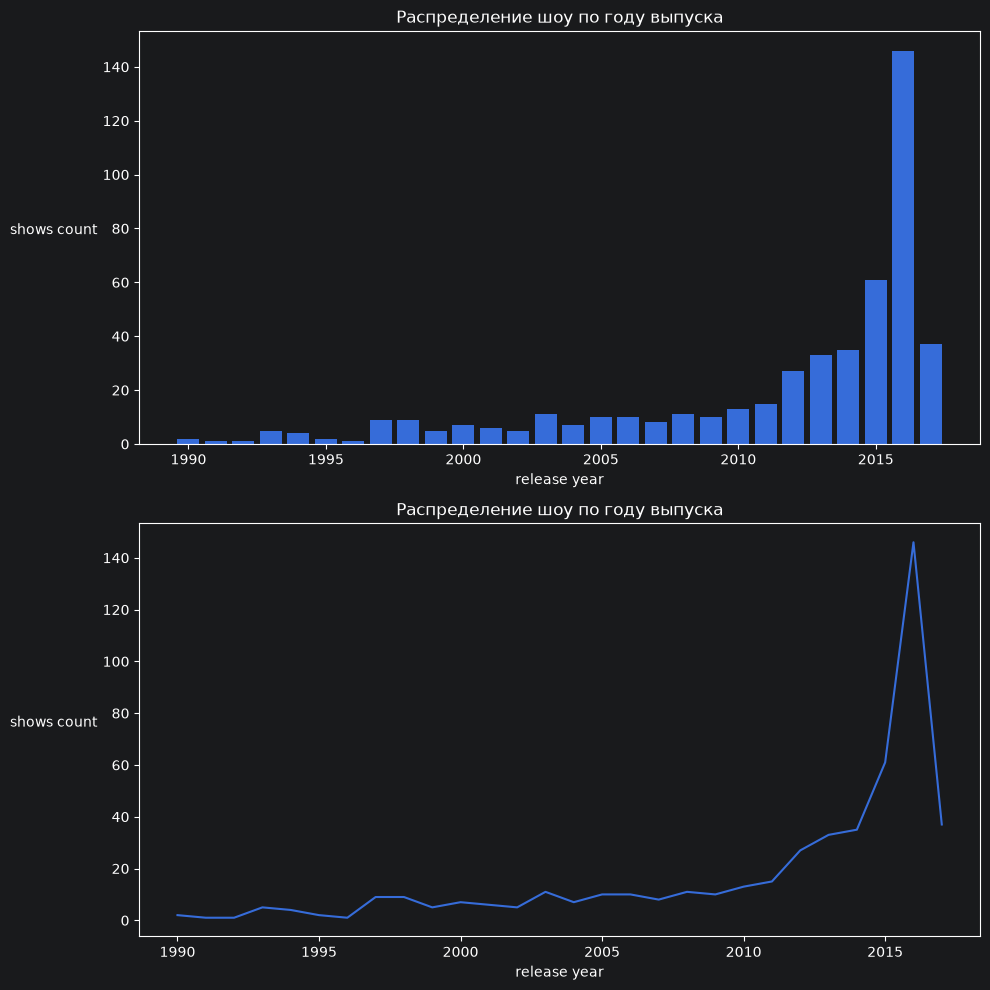

In [222]:
years = data[data['release year'] >= 1990].groupby('release year')['title'].count()
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].bar(years.index, years.values)
ax[0].set_xlabel('release year')
ax[0].set_ylabel('shows count', rotation=0, ha='right')
ax[0].set_title('Распределение шоу по году выпуска')
ax[1].plot(years.index, years.values)
ax[1].set_xlabel('release year')
ax[1].set_ylabel('shows count', rotation=0, ha='right')
ax[1].set_title('Распределение шоу по году выпуска')
plt.tight_layout()
plt.show()

### Распределение шоу по году выпуска

На графике представлено количество шоу в датасете в зависимости от года их выпуска. Начиная с 2012 года можно заметить постепенный рост количества контента, который особенно усиливается в последующие годы.

Одним из возможных объяснений является изменение контентной стратегии Netflix. В 2012 году на платформе вышел **Lilyhammer** — первый оригинальный сериал Netflix. В 2013 году появились такие проекты, как **House of Cards** и **Orange Is the New Black**, после чего компания продолжила активно расширять производство собственного контента.

Наиболее заметный рост наблюдается в 2016 году. Он может быть связан с дальнейшим масштабированием производства оригинального контента и международным расширением Netflix. Таким образом, начало роста в 2012 году можно рассматривать как один из признаков перехода Netflix к более активному созданию собственного контента.

In [202]:
first_metric2016 = data[(data['release year'] == 2016) & (data['user rating score'] > 80)]['title'].count() / data[data['release year'] == 2016].shape[0] * 100
first_metric2017 = data[(data['release year'] == 2017) & (data['user rating score'] > 80)]['title'].count() / data[data['release year'] == 2017].shape[0] * 100
second_metric2016 = data[(data['release year'] == 2016) & (data['user rating score'] > 80)]['title'].count()
second_metric2017 = data[(data['release year'] == 2017) & (data['user rating score'] > 80)]['title'].count()
print(f'2016 год: {second_metric2016} единиц контента с рейтингом выше 80, что составляет {first_metric2016:.1f}% от всего контента за год.')
print(f'2017 год: {second_metric2017} единиц контента с рейтингом выше 80, что составляет {first_metric2017:.1f}% от всего контента за год.')

2016 год: 55 единиц контента с рейтингом выше 80, что составляет 37.7% от всего контента за год.
2017 год: 13 единиц контента с рейтингом выше 80, что составляет 35.1% от всего контента за год.


### Сравнение контента с пользовательской оценкой выше 80

В 2016 году доля контента с пользовательской оценкой выше 80 составила **37.7%**
(**55** единиц контента).

В 2017 году доля такого контента составила **35.1%**
(**13** единиц контента).

Таким образом, сравниваются как абсолютное количество высокооценённого контента,
так и его доля от всего контента соответствующего года.

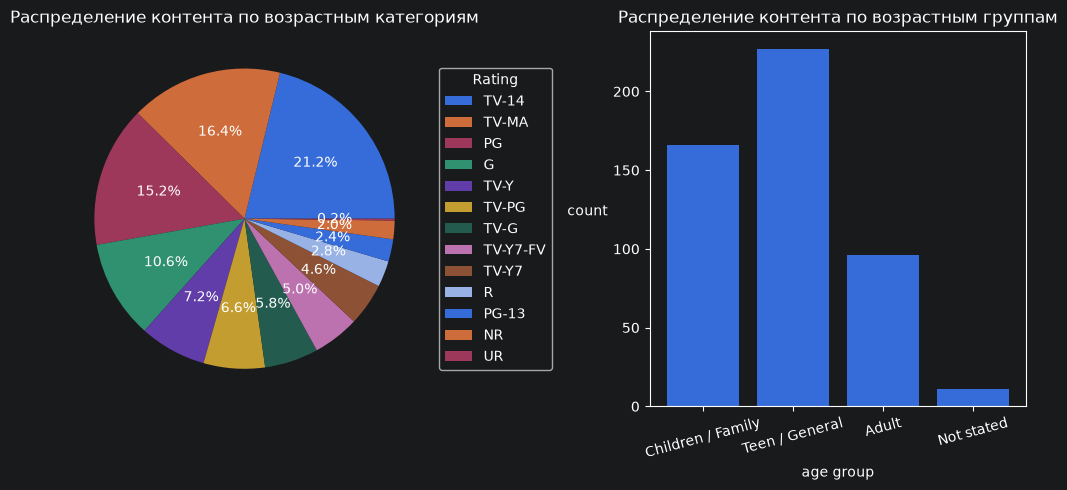

In [201]:
rating_groups = data.groupby('rating')['title'].size()
rating_groups = rating_groups.sort_values(ascending=False)
fig, axes = plt.subplots(1, 2 ,figsize=(10, 5))
axes[0].pie(rating_groups.values, autopct='%1.1f%%')
axes[0].set_title('Распределение контента по возрастным категориям')
axes[0].legend(rating_groups.index, title='Rating', loc='center left', bbox_to_anchor=(1, 0.5))
rating_groups = {
    'TV-Y': 'Children / Family',
    'TV-Y7': 'Children / Family',
    'TV-Y7-FV': 'Children / Family',
    'TV-G': 'Children / Family',
    'G': 'Children / Family',
    'TV-PG': 'Teen / General',
    'TV-14': 'Teen / General',
    'PG': 'Teen / General',
    'PG-13': 'Teen / General',
    'TV-MA': 'Adult',
    'R': 'Adult',
    'NR': 'Not stated',
    'UR': 'Not stated'
}
order = ['Children / Family', 'Teen / General', 'Adult', 'Not stated']
data['age group'] = data['rating'].map(rating_groups)
data['age group'] = pd.Categorical(data['age group'], categories=order, ordered=True)
age_groups = data.groupby('age group')['title'].count()
axes[1].bar(age_groups.index, age_groups.values)
axes[1].set_xlabel('age group')
axes[1].set_ylabel('count', rotation=0, ha='right')
axes[1].set_title('Распределение контента по возрастным группам')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Распределение контента по возрастным группам

Для упрощения анализа исходные возрастные рейтинги были объединены в четыре укрупнённые группы: **Children / Family**, **Teen / General**, **Adult** и **Not stated**.

На первом графике представлено распределение контента по исходным возрастным рейтингам. Наибольшую долю составляют категории **TV-14 (21,2%)** и **TV-MA (16,4%)**.

На втором графике показано количество записей в каждой укрупнённой возрастной группе. Наибольшее количество контента относится к категории **Teen / General — 227 записей**, далее следует **Children / Family — 166 записей**. В категории **Adult** находится 96 записей, а для 11 записей возрастная категория не указана.

Таким образом, после объединения отдельных рейтингов большая часть контента в рассматриваемой выборке относится к группам **Teen / General** и **Children / Family**.

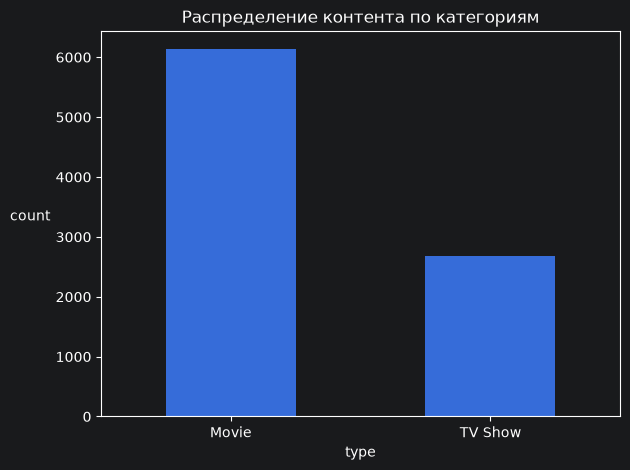

In [212]:
add_data = pd.read_csv('/Users/a111/Downloads/netflix_titles-2.csv')
add_data.groupby('type')['title'].count().plot(kind='bar')
plt.xlabel('type')
plt.ylabel('count', rotation=0, ha='right')
plt.xticks(rotation=0)
plt.title('Распределение контента по категориям')
plt.tight_layout()
plt.show()

### Распределение контента по категориям

Для расширения исходного набора данных был добавлен дополнительный датасет Netflix, найденный на платформе **Kaggle**.

На данном этапе рассматривается распределение контента по двум категориям: фильмы (**Movie**) и сериалы (**TV Show**).

На графике видно, что фильмов в датасете значительно больше, чем сериалов. Количество фильмов составляет около **6,1 тыс. записей**, тогда как сериалов — около **2,7 тыс.** Таким образом, в представленном датасете преобладают фильмы.

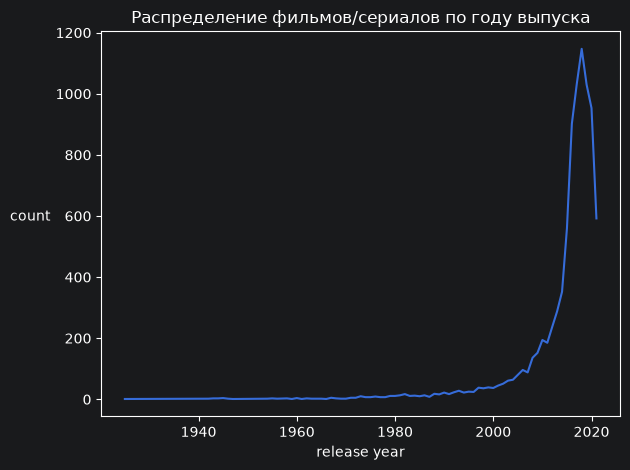

In [240]:
plt.plot(add_data.groupby('release_year')['title'].count())
plt.xlabel('release year')
plt.ylabel('count', rotation=0, ha='right')
plt.title('Распределение фильмов/сериалов по году выпуска')
plt.tight_layout()
plt.show()

### Проверка распределения контента по годам выпуска

Для проверки выявленной в первом датасете тенденции был проанализирован аналогичный показатель на основе дополнительного датасета Netflix, загруженного с платформы **Kaggle**.

На графике представлено распределение фильмов и сериалов по году выпуска. Полученная динамика практически совпадает с результатами анализа первого датасета: до начала 2000-х годов количество записей относительно невелико, затем наблюдается постепенный рост, который значительно ускоряется после 2010 года. Наибольшее значение приходится на период около **2018–2019 годов**, после чего количество записей снижается.

Таким образом, анализ второго датасета подтверждает выявленную ранее тенденцию увеличения объёма контента Netflix в последние годы. Это позволяет считать наблюдаемый рост характерным не только для первого набора данных, но и для более крупного дополнительного датасета.

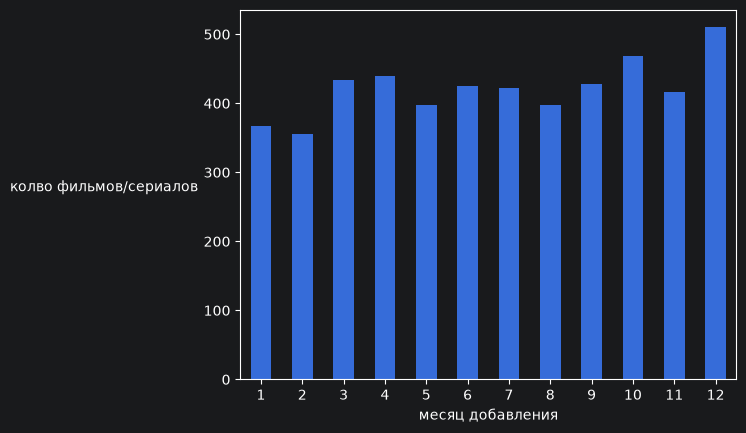

In [286]:
add_data['month_added'] = add_data['date_added'].dt.month.astype('Int64')
add_data[(add_data['release_year'] >= 2016) & (add_data['release_year'] <= 2020)].groupby('month_added')['title'].count().plot(kind='bar')
plt.xlabel('месяц добавления', rotation=0, ha='center')
plt.ylabel('колво фильмов/сериалов', rotation=0, ha='right')
plt.tick_params(axis='x', rotation=0)


### Анализ количества контента по месяцам добавления

Для анализа распределения контента по времени его добавления на Netflix из даты добавления был выделен месяц. Анализ проводился для контента с годом выпуска с 2016 по 2020 год.

На графике видно, что количество добавленного контента по месяцам изменяется неравномерно, однако выраженной сезонной тенденции не наблюдается. Минимальное количество записей приходится на февраль, а максимальное — на декабрь. При этом значения остальных месяцев находятся в относительно близком диапазоне.

Таким образом, на основе рассматриваемых данных нельзя выделить определённый месяц, в котором Netflix стабильно добавляет значительно больше или меньше контента.

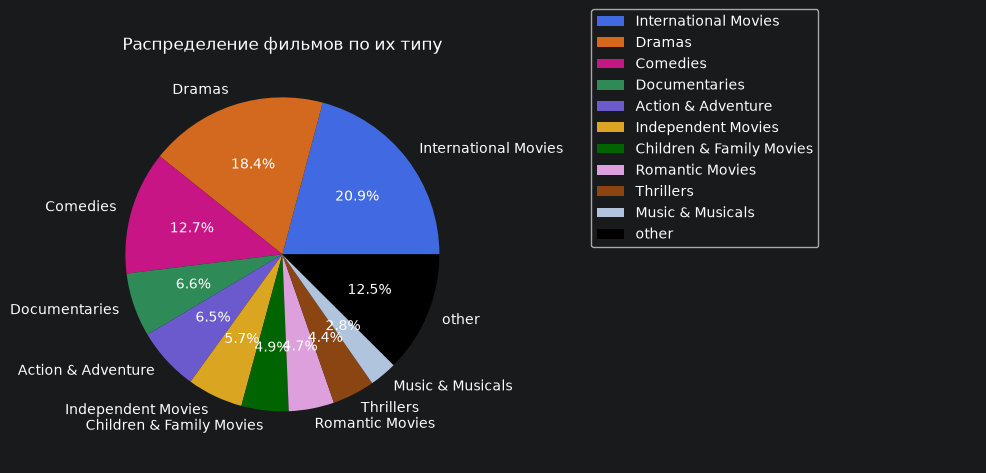

In [359]:
total_data = pd.merge(add_data, data, on='title', how='inner').reset_index(drop=True)
genres = add_data[add_data['type'] == 'Movie']['listed_in'].str.split(', ').explode()
genre_counts = genres.value_counts().head(10)
other = genres.value_counts().iloc[10:].sum()
genre_counts['other'] = other
colors = [
    'royalblue',
    'chocolate',
    'mediumvioletred',
    'seagreen',
    'slateblue',
    'goldenrod',
    'darkgreen',
    'plum',
    'saddlebrown',
    'lightsteelblue',
    'black'
]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%', colors=colors)
ax[0].set_title('Распределение фильмов по их жанрам')
ax[1].legend(ax[0].patches, genre_counts.index, loc='lower left', bbox_to_anchor=(0, 0.5))
ax[1].axis('off')
plt.tight_layout()

### Распределение фильмов по жанрам

Для анализа жанров были отобраны только фильмы, после чего значения из столбца `listed_in` были разделены на отдельные жанры. Поскольку один фильм может относиться сразу к нескольким жанрам, одна запись могла учитываться в нескольких категориях.

На графике представлены **10 наиболее распространённых жанров**, а остальные жанры объединены в категорию **Other**. Наиболее распространёнными являются **International Movies (20,9%)**, **Dramas (18,4%)** и **Comedies (12,7%)**. На остальные жанры приходится меньшая доля от общего количества упоминаний жанров.